<a href="https://colab.research.google.com/github/BrianaNzivu/Scancer/blob/main/Scancer_DetectorQuestionare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from imblearn.over_sampling import SMOTE
import seaborn as sns
import graphviz
import joblib

In [2]:
# Load the data
df = pd.read_csv('/content/bcsc_risk_factors_summarized1_092020.csv')



Index(['year', 'age_group_5_years', 'race_eth', 'first_degree_hx',
       'age_menarche', 'age_first_birth', 'BIRADS_breast_density',
       'current_hrt', 'menopaus', 'bmi_group', 'biophx',
       'breast_cancer_history', 'count'],
      dtype='object')


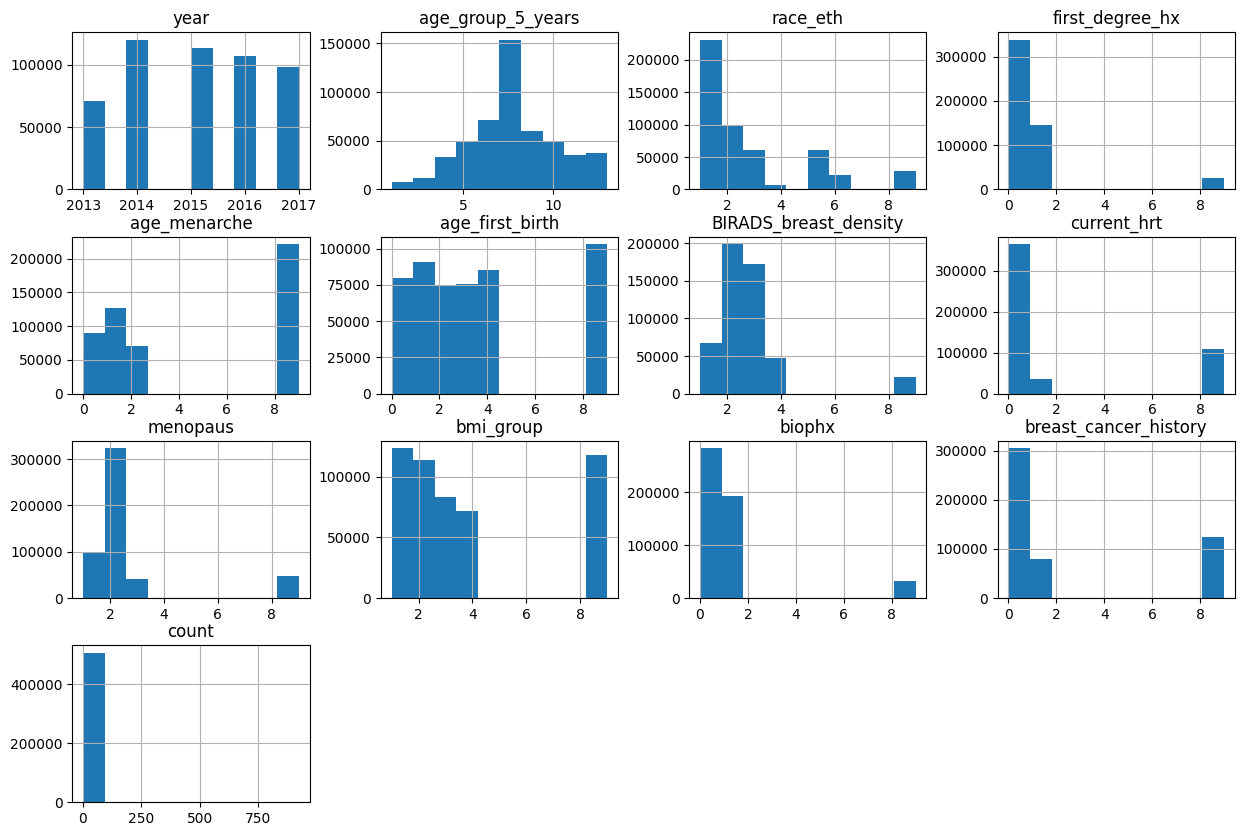

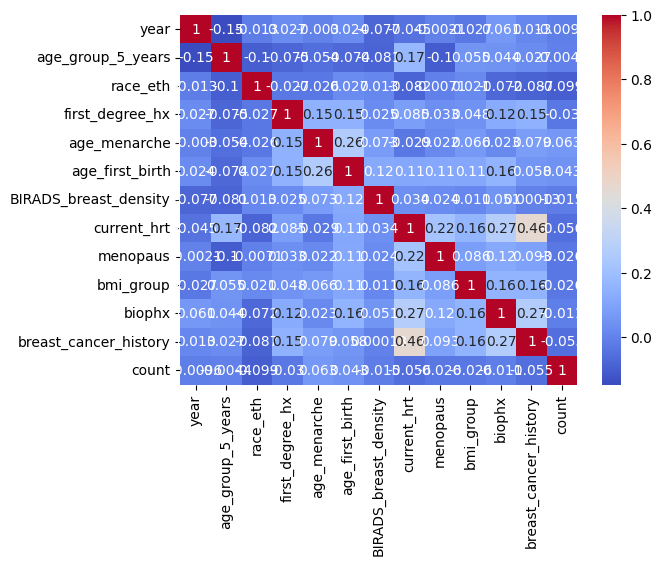

In [3]:
# Data exploration
print(df.columns)
df.hist(figsize=(15,10))
plt.show()

# Correlation heatmap
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# Handling Missing Values
df.fillna(df.median(), inplace=True)

# Encode categorical features
categorical_features = ['race_eth', 'first_degree_hx', 'age_menarche', 'age_first_birth',
                        'BIRADS_breast_density', 'current_hrt', 'menopaus', 'bmi_group', 'biophx']



In [5]:
for feature in categorical_features:
    df[feature] = df[feature].astype('category')

# Split features and target
X = df.drop('breast_cancer_history', axis=1)
y = df['breast_cancer_history']

# One-hot encode categorical features
X = pd.get_dummies(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to oversample the minority class
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Define the parameter grid to search for Decision Tree
param_grid_tree = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create and search for the best Decision Tree Classifier
tree = DecisionTreeClassifier(random_state=42)
grid_search_tree = GridSearchCV(tree, param_grid_tree, cv=5)
grid_search_tree.fit(X_train_resampled, y_train_resampled)

# Evaluate the Decision Tree model with the best parameters
best_tree = grid_search_tree.best_estimator_
y_pred_tree = best_tree.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_tree))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))



Decision Tree Accuracy: 0.6186765081172336
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.53      0.66     61195
           1       0.35      0.81      0.49     16019
           9       0.62      0.72      0.67     24668

    accuracy                           0.62    101882
   macro avg       0.62      0.69      0.61    101882
weighted avg       0.74      0.62      0.64    101882

Decision Tree Confusion Matrix:
 [[32216 19247  9732]
 [ 1658 12996  1365]
 [ 2218  4630 17820]]


In [6]:
# Visualize the best Decision Tree
dot_data = export_graphviz(best_tree,
                           feature_names=X.columns,
                           class_names=['No Risk', 'Risk', 'Unknown'],
                           filled=True,
                           rounded=True,
                           special_characters=True)

graph = graphviz.Source(dot_data)
graph.render("decision_tree")



'decision_tree.pdf'

In [7]:
# Save the best model (Decision Tree in this case)
joblib.dump(best_tree, 'best_tree_model.pkl')


['best_tree_model.pkl']

In [8]:

# Function to predict new user input
def predict_risk(user_input):
    # Preprocess user input to match training data format
    user_input_df = pd.DataFrame(user_input, index=[0])
    user_input_df = pd.get_dummies(user_input_df)
    user_input_df = user_input_df.reindex(columns=X.columns, fill_value=0)

    # Load the model
    model = joblib.load('best_tree_model.pkl')

    # Predict
    prediction = model.predict(user_input_df)
    probability = model.predict_proba(user_input_df)

    return {'prediction': prediction[0], 'probability': probability[0]}

# Example user input (needs to match your feature space)
user_input_example = {
    'Age (years) in 5 year groups': 1,
    'race_eth': 1,
    'first_degree_hx': 0,
    'age_menarche': 1,
    'age_first_birth': 1,
    'BIRADS_breast_density': 2,
    'current_hrt': 0,
    'menopaus': 1,
    'bmi_group': 2,
    'biophx': 0
}
